In [59]:
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pandas.api.types import CategoricalDtype
import scipy as sp
from pathlib import Path
import tkinter as tk
from tkinter import filedialog
import itertools
from colour import Color
from datetime import date
import statsmodels.api as sm
from statsmodels.stats.weightstats import ztest as ztest
from sklearn.metrics import r2_score as R2S
import cairo

from lmfit import Model

In [2]:
today = date.today()
print("Today's date:", today)
date = str(today)
date

Today's date: 2024-01-11


'2024-01-11'

In [19]:
tubulin = '[Tubulin] (' r'$\mu$' 'M)'
tub = 'tub'

DCXconc = '[DCX] (nM)' 
EBconc = '[EB] (nM)'
DCX = 'DCX'
Type = 'DCX Type'

Concentration = 'Concentration (' r'$\mu$' 'M)'
Length = 'Length (' r'$\mu$' 'm)'
Lifetime = 'Lifetime (min)'
GrowthRate = 'Growth Rate (' r'$\mu$' 'm/min)'
TimeToNucleate = 'Time to Nucleate (min)'
ShrinkageLength = 'Shrink Length (' r'$\mu$' 'm)'
ShrinkageLifetime = 'Shrink Lifetime (min)'
ShrinkageRate = 'Shrink Rate (' r'$\mu$' 'm/min)'
RescuePerLength = 'Rescues (' r'$\mu$' 'm' r'$^{-1}$' ')'

In [4]:
Type_order = ['None', 'Y64N','R76S','R102S', 'R178L', 'P191R', 'G223E','R303X', 'WT']

category_Type = CategoricalDtype(Type_order, ordered=True,) #order mutants

In [29]:
black = '#000000'
grey = '#777777'
blue = '#23459C'
cyan = '#0089CF'
green = '#79BA1A'
purple = '#AB4A9C'
lily = '#CB81EA'
magenta = '#D80B8C'
red = '#e60000'
orange = '#FF7300'
darkorange = '#FF5B00'
lightorange = '#FFAC83'
yellow = '#FFCB05'
lightyellow = '#F9DC2D'
pink = '#FFA4CD'
StartHue1 = Color(purple)
DC1color = list(StartHue1.range_to(Color(pink),3))
StartHue2 = Color(darkorange)
DC2color = list(StartHue2.range_to(Color(lightorange),3))
print(DC1color,DC2color)

palette = [grey] + list(map(Color.get_hex,DC1color)) + list(map(Color.get_hex,DC2color)) + [green,cyan]

parameters = [GrowthRate,TimeToNucleate,Lifetime,ShrinkageRate]

[<Color #ab4a9c>, <Color #e468b8>, <Color #ffa4cd>] [<Color #ff5b00>, <Color #ff8341>, <Color #ffac83>]


In [60]:
### font for matplotlib
matplotlib.rcParams['font.family'] = 'Helvetica Neue LT Std'

#  Open saved fit parameters  #

In [6]:
askFitParam = filedialog.askopenfilename() # show an "Open" dialog box and return the path to the selected file
ResultFit = pd.read_csv(askFitParam, encoding='utf-8')
ResultFit[Type] = ResultFit[Type].fillna('None')
ResultFit

,Fit,SE,Coefficient,[Tubulin] ($\mu$M),DCX Type,[DCX] (nM),Parameter,Moment
0,1.070577,0.008903,0.0,12,None,0,Growth Rate ($\mu$m/min),Mean
1,0.157043,0.007290,1.0,12,None,0,Growth Rate ($\mu$m/min),Std
2,0.797346,0.025314,0.0,8,None,0,Growth Rate ($\mu$m/min),Mean
3,0.149149,0.020669,1.0,8,None,0,Growth Rate ($\mu$m/min),Std
4,0.416686,0.002427,0.0,6,None,0,Growth Rate ($\mu$m/min),Mean
...,...,...,...,...,...,...,...,...
363,5.080860,0.468668,1.0,14,None,0,Shrink Rate ($\mu$m/min),Std
364,19.051355,0.549069,0.0,10,None,0,Shrink Rate ($\mu$m/min),Mean
365,5.591572,0.456008,1.0,10,None,0,Shrink Rate ($\mu$m/min),Std
366,12.426828,0.919834,0.0,7,None,0,Shrink Rate ($\mu$m/min),Mean


In [7]:
newmydir = Path(askFitParam).parent
newmydir

WindowsPath('C:/Users/Brouhard Lab/OneDrive - McGill University/EJCB2023/Sofia_EJCB_Figs/Data/2023-08-08_fitdata-final')

## dcx EQ FIT ##

In [32]:
def pickdata(dcxtype, parameterNo):
    dcxtype_DF = ResultFit[(ResultFit[Type]==dcxtype) & (ResultFit['Moment']=='Mean')& (ResultFit[tubulin]==6)]

    parameterMeanDF = dcxtype_DF[dcxtype_DF['Parameter']==parameters[parameterNo]]

    x = parameterMeanDF[DCXconc].values
    y = parameterMeanDF['Fit'].values
    yerr = parameterMeanDF['SE'].values
    
    return x,y,yerr

In [35]:
def hillEQ(x, n, kd, Y):
    return  (YL[-1]- Y[0]) * np.power(x, n)/(kd + np.power(x, n)) + Y[0]

In [52]:
def reduced_chi_squared(obs,fit,sigma,freedom): 

    return np.sum(np.square(fit - obs)/np.square(sigma)) / freedom

In [36]:
x,y,yerr = pickdata('WT', 2)
x0,y0,yerr0 = pickdata('None', 2)

X = [*x0,*x]
YL = [*y0,*y]
YerrL = [*yerr0,*yerr]

logx = np.log(X[1:-1])
normyL =( YL[1:-1]-YL[0])/(YL[-1]-YL[0])
logyL = np.log(normyL/(1-normyL))

p, cov = np.polyfit(logx, logyL, 1, cov=True)
var = np.diagonal(cov) #Refer [3]
SElin = np.sqrt(var) #Refer [4]

mL,bL = p


p, SElin

(array([  3.24769793, -13.0913579 ]), array([0.5427463 , 2.26854382]))

In [57]:
linfitYL = np.multiply(logx,mL) + bL

In [38]:
R2S(logyL,logx*mL+bL)

0.9470985416685979

In [42]:

fitYL = hillEQ(X,p[0], np.exp(-p[1]),YL)
fitYL

array([ 3.84602165,  5.07852635,  8.41376882, 10.56691598, 11.98210304,
       12.70987654])

In [49]:
v = len(YL) - 2

In [53]:
reduced_chi_squared(YL,fitYL,YerrL,v)

0.046920562085981096

In [72]:
def hill_plot_fitMUT(dcxtype):
    x,y,yerr = pickdata(dcxtype, 2)
    x0,y0,yerr0 = pickdata('None', 2)

    X = np.array(x)
    YLmut = np.array(y)
    YerrLmut = yerr

    logxmut = np.log(X[1:])
    normyL =( YLmut[1:]-YLmut[0])/(YL[-1]-YLmut[0])
    logyLmut = np.log(normyL/(1-normyL))

    pmut, cov = np.polyfit(logxmut, logyLmut, 1, cov=True)
    var = np.diagonal(cov) #Refer [3]
    SElinmut = np.sqrt(var) #Refer [4]

    return    pmut, SElinmut


In [82]:
x,y,yerr = pickdata('R76S', 2)
x0,y0,yerr0 = pickdata('None', 2)

X = np.array(x)
YL76 = np.array(y)
YerrL76 = yerr

p76 , SE76 = hill_plot_fitMUT('R76S')
p76 , SE76

(array([  3.22323167, -17.71173874]), array([1.08894694, 5.08725883]))

In [76]:
fitYL76 = hillEQ(X,p76[0], np.exp(-p76[1]),YL76)
fitYL76

array([3.46563959, 3.5381493 , 3.69424532, 4.19801844, 7.60299689])

In [77]:
reduced_chi_squared(YL76,fitYL76,YerrL76,v)

1.2224861527628934

In [88]:
#K_A76
np.exp(-p76[1]/p76[0])

243.47762499225308

In [83]:
x,y,yerr = pickdata('P191R', 2)
x0,y0,yerr0 = pickdata('None', 2)

X = np.array(x)
YL191 = np.array(y)
YerrL191 = yerr

p191 , SE191 = hill_plot_fitMUT('P191R')
p191 , SE191

(array([  2.50104811, -14.14968789]), array([0.3204507 , 1.49705701]))

In [84]:
fitYL191 = hillEQ(X,p191[0], np.exp(-p191[1]),YL191)
fitYL191

array([2.98682482, 3.11682823, 3.32422615, 3.84095945, 6.48124947])

In [85]:
reduced_chi_squared(YL191,fitYL191,YerrL191,v)

0.05548011489598395

In [90]:
def K_A(p):
    return np.exp(-p[1]/p[0]) , np.exp(-p[1]/p[0])/p[0]*np.sqrt(np.square(SElin[1])+np.square(p[1]*SElin[0]/p[0]))

In [93]:
K_A(p)

(56.31525016671599, 54.64929293593946)

In [91]:
K_A(p76)

(243.47762499225308, 283.05249199530596)

In [92]:
K_A(p191)

(286.43260895654004, 437.2218206763217)

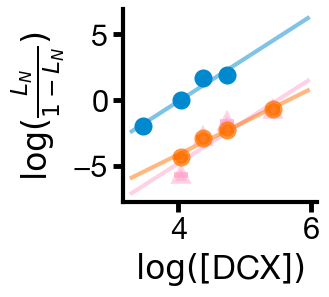

In [71]:
scattersize = 9
cap = 5

fig, ax = plt.subplots(1,1,figsize=(2.5,2.5))
ax.errorbar(logx , logyL , yerr= 0 , fmt='',marker='o', markersize=scattersize,capsize = cap,
                              markeredgewidth=4,color=cyan, alpha = 1, ls='')
ax.errorbar(logx76 , logyL76 , yerr= 0 , fmt='',marker='^', markersize=scattersize,capsize = cap,
                              markeredgewidth=4,color=pink, alpha = 0.5, ls='')
ax.errorbar(logx191 , logyL191 , yerr= 0 , fmt='',marker='o', markersize=scattersize,capsize = cap,
                              markeredgewidth=4,color=orange, alpha = 0.75, ls='')


x0 = np.arange(3.3, 6, 0.05)

ax.plot(x0, x0*mL+bL,color = cyan, lw=3,ls= '-',alpha = 0.5)
ax.plot(x0, x0*mL76+bL76,color = pink, lw=3,ls= '-',alpha = 0.5)
ax.plot(x0, x0*mL191+bL191,color = orange, lw=3,ls= '-',alpha = 0.5)
# ax.set_ylim(-2.5,2.5)
# ax.set_xlim(3,5)
ax.set_xlabel(r'$\log([$''DCX' r'$])$')
#ax.set_xticks(np.arange(0, 22.1, 2))
#ax.set_yticks(np.arange(0, 150.1, 25))
ax.set_ylabel(r'$\log(\frac{L_N}{1-L_N})$') 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_lw(3)
ax.spines['bottom'].set_lw(3)
ax.tick_params(axis='both', width = 3.5, length = 7)

#ax.legend((r'$n=2.94 \pm 0.49$' '\n' r'$R^2 > 0.945$',),loc='lower right',title='Hill Equation')

sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})

#plt.savefig(newmydir/('logexpHillfit_Lifetime_'+date+'.pdf'), bbox_inches = 'tight')